# Majorant_v2 — CLOSED cascades (cases 1 and 2), BASELINE engine

Split out of `Run_four_cases_no_resampling.ipynb`. This notebook holds the two **closed**
configurations; the two open ones live in `Run_open_no_resampling_v2.ipynb`.

Uses **`BF_v_no_resampling_v2.py`**: one simulated particle is one physical particle,
$w\equiv1$ for the whole run. There is no weight bookkeeping anywhere, so

- $\sum w$ and $\sum wm$ are conserved to machine precision — `mass_drift` is *identically zero*
  and any nonzero value is a bug, not a fluctuation;
- the clock is simply $dt=2V/R$, with nothing that can silently rescale it;
- nothing is resampled, so nothing can bias the answer.

The price is **range**. In a closed box $N=N_{\rm i}m_{\rm i}/m_0$, so reaching $D$ decades while
keeping $K$ particles alive at the top needs $N_{\rm i}\ge K\cdot10^{D}$ — about
$D\le\log_{10}N_{\rm i}-3$ decades for usable statistics. Fragmentation fails the other way:
$N$ grows as $m_{\rm i}/m_0$, so three decades multiply the population a thousandfold and memory,
not physics, ends the run.

For ten decades use `BF.py` (multiplication + down-sampling); the two agree wherever both can run.

| # | process | system | boundary conditions |
|---|---|---|---|
| 1 | coagulation  | closed | none — mass exactly conserved |
| 2 | fragmentation| closed | passive floor only — mass exactly conserved |

## What the analytic part predicts

$$\frac{dm_0}{d\tau}=\int n(m)\,K(m_0,m)\,\Delta m(m_0,m)\,dm ,\qquad x=m/m_0,\ dm=m_0\,dx$$

Kernel homogeneity, the per-event mass change and the Jacobian always contribute
$m_0^{\lambda}\cdot m_0\cdot m_0$, so the only difference between the cases is the power of
$m_0$ carried by $n$:

$$\beta=\lambda+2+\begin{cases}-2 & \text{closed: packet}\propto m_0^{-2}\\ \ \ \alpha & \text{open: background}\propto m_0^{\alpha}\end{cases}
\qquad b=\frac{1}{1-\beta},\qquad \alpha=-(1+\beta)$$

| | $\beta$ | $b$ | $\alpha$ |
|---|---|---|---|
| **closed** | $\lambda$ | $1/(1-\lambda)$ | $-(1+\lambda)$ |
| **open**   | $(1+\lambda)/2$ | $2/(1-\lambda)$ | $-(3+\lambda)/2$ |

Coagulation and fragmentation share $\beta$, $b$ and $\alpha$ exactly — only the sign of the drift
flips, so the law is read in $\tau$ going up and in $\tau_*-\tau$ going down.

**Constant kernel, $\lambda=0$:** closed $b=1$, $\alpha=-1$.

## How the spectrum is measured here

No steady state exists in a closed box. Use the superposition $F(m)=\sum_t(dN/dm)\Delta t$
(`BF.superpose`), and place snapshots with `snapshot_mode="log_m0"`.

> ### Engine: `BF_v_no_resampling_v2.py`
>
> Same physics, same majorant, same clock and the same analysis helpers as
> `BF_v_no_resampling.py`. Four additions, all about the **sink as a criterion**:
>
> 1. `iso_start_sink` now defaults to **10** and applies to coagulation *and* fragmentation
>    alike — the sink is the sink, whichever end of the cascade it sits at. Isochrone
>    accumulation waits until 10 physical particles have crossed the whole inertial range.
> 2. A closed system has no sink, so that default is silently disarmed there; only an
>    explicitly passed value still raises.
> 3. `stop_sink_events` (new, default `None`) — stop the run on the sink count. `max_events`
>    is a statement about *resources*; this one is a statement about the *physics*.
> 4. `out["n_out"]` (new) — the sink counter as a per-snapshot time series, next to the
>    existing final scalar `out["sink_events"]`.
>
> The original `BF_v_no_resampling.py` and `Run_four_cases_no_resampling.ipynb` are untouched.



> ### ⚠ `snapshot_mode` — the one setting that decides whether a closed run measures anything
>
> The closed estimator is a Riemann sum $F(m)=\sum_k (dN/dm)(m,t_k)\Delta t_k$, and the sampling
> of $t$ has **two separate jobs**: *placement* decides what is resolved, *weight* (always the
> actual $\Delta t$) decides what is computed.
>
> | placement | what happens | measured $\alpha$ (theory $-1$) |
> |---|---|---|
> | `events` | events per unit $m_0$ fall as $1/m_0^2$, so $\Delta t$ explodes; **94 % of the weight lands in one snapshot** | $-1.4\ldots-2.6$ |
> | `t_phys`, narrow range | fine over $\lesssim2$ decades | $-0.97\ldots-1.02$ ✓ |
> | `t_phys`, wide range | $t\propto m_0$, so uniform $t$ is uniform $m_0$; over ten decades the lower **five get no sample at all** | $-0.04\pm0.16$ |
> | **`log_m0`** | $k$ snapshots per decade of $m_0$, everywhere | **$-1.005$, $R^2=0.9995$** |
>
> Beware: with `events` the plateau finder still reports a clean 1-decade plateau at
> $-1.375\pm0.14$. An internally consistent, entirely wrong measurement — **fitting the plateau
> cannot rescue a broken estimator**, because it tests whether the curve you computed has a
> scaling region, not whether that curve is the right quantity. The independent guard is the
> printed weight of the last snapshot: it must be $\ll1\%$.
>
> **Rule.** Closed system → `snapshot_mode="log_m0"`, stride = snapshots per decade (20–30).
> Open system → the steady state is the *last* snapshot, $\Delta t$ never enters, any cadence works.
>
> This baseline engine has no weights at all, so the *other* trap — $w$ missing from
> $dt=2V/(wR)$, which turns a power-law drift into a fake exponential and locks the index onto
> $-2$ for any kernel — cannot occur here by construction.



> ### ⚠ Fit only the inertial range — never the whole array
>
> A measured spectrum is a power law only *between* the two characteristic masses of the
> problem. Outside that band it bends: at the injection scale by the source, at the sink (or
> at the largest $m_0$ actually reached) by truncation and by vanishing statistics. A single
> fit across the whole array averages the plateau together with both bends and returns a
> number describing neither.
>
> Measured on the same closed-coagulation run, $\lambda=0$, theory $\alpha=-1.000$:
>
> | fit range | $\alpha$ |
> |---|---|
> | whole array | **$-1.71$** |
> | guard band, $\pm0.5$ dex inside $[m_{\rm i},\,m_0^{\max}]$ | $-1.09$ |
> | automatic plateau in the local slope | $-1.16\pm0.15$ over 1.3 decades |
>
> Two tools in `BF.py`, and they should agree:
> - `BF.local_slope(m, F)` — $\Gamma(m)=d\log F/d\log m$ on a sliding window. A genuine
>   inertial range is a **plateau** in $\Gamma$; the bends mark the contaminated ends. Plot it
>   under every spectrum, as in the lower subpanels of Laor & Gitelman (2026).
> - `BF.find_inertial_range(m, F)` — the longest contiguous run where $\Gamma$ is flat within
>   `tol`, returning the window, $\alpha$, and its scatter. If it returns `nan`, the run has no
>   inertial range yet — which is the correct answer, not a failure.
> - `BF.guard_band(m_low, m_high)` — the a-priori band: strip 0.5 dex from each end of
>   $[m_{\rm inj},\,m_{\rm sink}]$ (open) or $[m_{\rm i},\,m_0^{\max}]$ (closed). Use it as an
>   independent cross-check.


In [1]:
import importlib, numpy as np, matplotlib.pyplot as plt
import BF_v_no_resampling_v2 as BF          # <-- v2 baseline engine, w == 1
importlib.reload(BF)

plt.rcParams.update({"figure.dpi":110, "font.size":9, "axes.grid":True,
                     "grid.alpha":0.25, "figure.figsize":(9,3.2)})

KERNEL = BF.kernel_constant          # lambda = 0 ; swap for BF.kernel_geometric (2/3), etc.
LAM    = BF.KERNEL_LAMBDA[KERNEL.__name__]
EDGES  = 10.0 ** np.arange(-4, 7, 0.1)

print("engine =", BF.__name__)
print("kernel =", KERNEL.__name__, " lambda =", LAM)
for sysname in ("closed", "open"):
    p = BF.predict(sysname, LAM)
    print("  %-7s beta = %.4g   b = %.4g   alpha = %.4g" % (sysname, p["beta"], p["b"], p["alpha"]))

RESULTS = {}   # collected for the summary table at the end


engine = BF_v_no_resampling_v2
kernel = kernel_constant  lambda = 0.0
  closed  beta = 0   b = 1   alpha = -1
  open    beta = 0.5   b = 2   alpha = -1.5


---
## 1. Closed system + coagulation

No injection, no sink: total mass exactly conserved. The run stops when the characteristic
mass reaches `stop_max_mass`.

**Two checks.**
1. *Clock / growth law.* For the constant kernel the closed box is solved exactly,
   $n(t)=n_0/(1+n_0K_1t/2)$, so $m_0(t)=m_{\rm i}(1+n_0K_1t/2)$ — a **straight line on
   linear axes**. If instead $\ln m_0$ is linear in $t$, the particle weights are missing
   from $\Delta t$ and every measured index collapses onto $-2$.
2. *Spectrum.* The age-integrated superposition should give $\alpha=-(1+\lambda)=-1$.

In [2]:
# No resampling: N = N_i m_i/m0, so the population is spent as m0 grows.
# Choose N0 so that ~1000 particles survive at the top: D <= log10(N0) - 3.
N0, M_INIT, STOP = 10_000_000, 1.0, 1e5          # ~3 decades, ~1000 particles left
r1 = BF.simulate(process="coagulation", system="closed", kernel=KERNEL, edges=EDGES,
                 ic={"m":M_INIT, "N":N0}, stop_max_mass=STOP,
                 snapshot_mode="log_m0", snapshot_stride=30,
                 rng=np.random.default_rng(1), verbose=False)

print("snapshots = %d | live: %d -> %d | w = %.3g (constant) | mass_drift = %+.2e (must be 0)"
      % (len(r1["t"]), r1["live"][0], r1["live"][-1], r1["final_weight"], r1["mass_drift"]))
dt1 = np.diff(r1["t"], prepend=r1["t"][0])
print("snapshots = %d | weight of the LAST snapshot = %.2f%%  (must be << 1%%)"
      % (len(r1["t"]), 100*dt1[-1]/dt1.sum()))

print("live %d -> %d | stop = %s" % (r1["live"][0], r1["live"][-1], r1["stop_reason"]))
print("mass conserved: %.8g -> %.8g" % (r1["M_sys"][0], r1["M_sys"][-1]))

exact = BF.exact_closed_constant(r1["t"], M_INIT, N0, 1.0, "coagulation")
sel   = r1["m_mean"] > 10                     # fit only the self-similar regime m0 >> m_i
g1    = BF.growth_fit(r1["t"], r1["m_mean"], mask=sel)
F1    = BF.superpose(r1["dndm"], r1["t"])
ir1   = BF.find_inertial_range(r1["centers"], F1)
gb1   = BF.guard_band(M_INIT, r1["m_mean"][-1], 0.5)
f1    = BF.fit_powerlaw(r1["centers"], F1, *gb1)
pr1   = BF.predict("closed", LAM)

print("\nm0 vs EXACT : max |ratio-1| = %.2e     <-- clock check" %
      np.nanmax(np.abs(r1["m_mean"]/exact - 1)))
print("growth law  : b = %.3f  (theory %.3f)   R2_power=%.4f  R2_exp=%.4f" %
      (g1["b"], pr1["b"], g1["r2_power"], g1["r2_exp"]))
print("spectrum, guard band [%.3g,%.3g] : alpha = %+.3f  (theory %+.3f)  R2=%.3f"
      % (gb1[0], gb1[1], f1["alpha"], pr1["alpha"], f1["r2"]))
print("spectrum, auto plateau [%.3g,%.3g] : alpha = %+.3f +- %.3f  over %.2f decades"
      % (ir1["m_lo"], ir1["m_hi"], ir1["alpha"], ir1["scatter"], ir1["decades"]))
print("spectrum, WHOLE ARRAY (wrong)     : alpha = %+.3f"
      % BF.fit_powerlaw(r1["centers"], F1, r1["centers"][F1>0].min(), r1["centers"][F1>0].max())["alpha"])
RESULTS["1 closed coag"] = dict(b=g1["b"], b_th=pr1["b"], alpha=ir1["alpha"],
                                alpha_th=pr1["alpha"], scatter=ir1["scatter"],
                                decades=ir1["decades"], alpha_gb=f1["alpha"])

snapshots = 120 | live: 10000000 -> 1088 | w = 1 (constant) | mass_drift = +0.00e+00 (must be 0)
snapshots = 120 | weight of the LAST snapshot = 6.21%  (must be << 1%)
live 10000000 -> 1088 | stop = stop_max_mass
mass conserved: 10000000 -> 10000000

m0 vs EXACT : max |ratio-1| = 7.84e-14     <-- clock check
growth law  : b = 0.990  (theory 1.000)   R2_power=0.9999  R2_exp=0.6194
spectrum, guard band [3.16,2.91e+03] : alpha = -1.035  (theory -1.000)  R2=0.990
spectrum, auto plateau [7.08,3.55e+03] : alpha = -1.077 +- 0.126  over 2.70 decades
spectrum, WHOLE ARRAY (wrong)     : alpha = -1.393


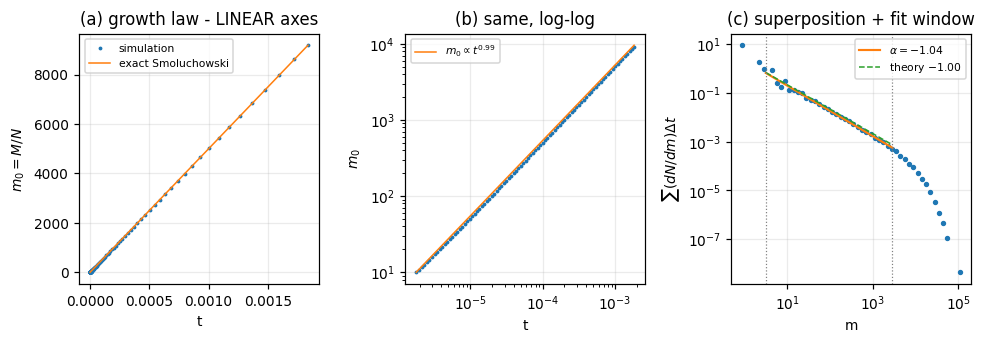

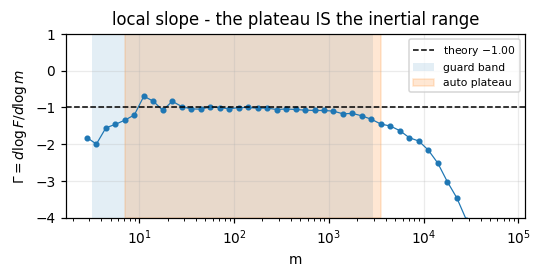

In [3]:
fig, ax = plt.subplots(1, 3)
ax[0].plot(r1["t"], r1["m_mean"], ".", ms=3, label="simulation")
ax[0].plot(r1["t"], exact, "-", lw=1, label="exact Smoluchowski")
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"$m_0=M/N$"); ax[0].legend(fontsize=7)
ax[0].set_title("(a) growth law - LINEAR axes")

tt = r1["t"][sel]
ax[1].loglog(tt, r1["m_mean"][sel], ".", ms=3)
ax[1].loglog(tt, r1["m_mean"][sel][0]*(tt/tt[0])**g1["b"], "-", lw=1,
             label=r"$m_0\propto t^{%.2f}$" % g1["b"])
ax[1].set_xlabel("t"); ax[1].set_ylabel(r"$m_0$"); ax[1].legend(fontsize=7)
ax[1].set_title("(b) same, log-log")

# (c) superposed spectrum with the fit windows marked
ax[2].loglog(r1["centers"], np.where(F1>0, F1, np.nan), "o", ms=2.5)
xs = np.logspace(np.log10(gb1[0]), np.log10(gb1[1]), 30)
ax[2].loglog(xs, f1["A"]*xs**f1["alpha"], "-", lw=1.4, label=r"$\alpha=%.2f$" % f1["alpha"])
ax[2].loglog(xs, f1["A"]*xs**pr1["alpha"], "--", lw=1, label=r"theory $%.2f$" % pr1["alpha"])
for v in gb1: ax[2].axvline(v, ls=":", lw=.8, color="0.5")
ax[2].set_xlabel("m"); ax[2].set_ylabel(r"$\sum (dN/dm)\Delta t$")
ax[2].legend(fontsize=7); ax[2].set_title("(c) superposition + fit window")
fig.tight_layout()

# --- the diagnostic that decides the window: local slope -------------------
fig2, a2 = plt.subplots(figsize=(5,2.6))
mm, G = BF.local_slope(r1["centers"], F1)
a2.semilogx(mm, G, "o-", ms=3, lw=.8)
a2.axhline(pr1["alpha"], ls="--", lw=1, color="k", label=r"theory $%.2f$" % pr1["alpha"])
a2.axvspan(gb1[0], gb1[1], alpha=.12, label="guard band")
if np.isfinite(ir1["m_lo"]):
    a2.axvspan(ir1["m_lo"], ir1["m_hi"], alpha=.18, color="C1", label="auto plateau")
a2.set_ylim(-4, 1); a2.set_xlabel("m"); a2.set_ylabel(r"$\Gamma=d\log F/d\log m$")
a2.legend(fontsize=7); a2.set_title("local slope - the plateau IS the inertial range")
fig2.tight_layout()

---
## 2. Closed system + fragmentation

Mirror image of case 1. Mass again exactly conserved; `min_frag_mass` is a **passive** floor
(particles below it stop fragmenting), so nothing is removed.

Exact reference: $n(t)=n_0/(1-n_0K_1t/2)$, hence $m_0(t)=m_{\rm i}(1-n_0K_1t/2)$ — again a
**straight line on linear axes**, now sloping down, reaching zero at $t_*=2/(n_0K_1)$.
Same $b=1$, same $\alpha=-1$: *the exponents do not know which way the cascade runs.*

In [4]:
# No thinning: N grows as m_i/m0, so the range is capped by MEMORY.
# live_end ~ N0 * (m_init/floor); keep that under a few million.
N0F, M_INIT_F, FLOOR = 3000, 1e5, 1.0          # ~3 decades, live_end ~ 3e6
r2 = BF.simulate(process="fragmentation", system="closed", kernel=KERNEL, edges=EDGES,
                 ic={"m":M_INIT_F, "N":N0F}, min_frag_mass=FLOOR,
                 snapshot_mode="log_m0", snapshot_stride=30, max_events=4e6,
                 rng=np.random.default_rng(2), verbose=False)

print("snapshots = %d | live: %d -> %d | w = %.3g (constant) | mass_drift = %+.2e (must be 0)"
      % (len(r2["t"]), r2["live"][0], r2["live"][-1], r2["final_weight"], r2["mass_drift"]))
dt2 = np.diff(r2["t"], prepend=r2["t"][0])
print("snapshots = %d | weight of the LAST snapshot = %.2f%%  (must be << 1%%)"
      % (len(r2["t"]), 100*dt2[-1]/dt2.sum()))

print("live %d -> %d | <m> %.4g -> %.4g" % (r2["live"][0], r2["live"][-1],
                                            r2["m_mean"][0], r2["m_mean"][-1]))
print("mass conserved: %.8g -> %.8g" % (r2["M_sys"][0], r2["M_sys"][-1]))

sel2   = r2["m_mean"] > 3
r2_lin = np.corrcoef(r2["t"][sel2], r2["m_mean"][sel2])[0,1]**2
r2_exp = np.corrcoef(r2["t"][sel2], np.log(r2["m_mean"][sel2]))[0,1]**2
print("\nm0(t): LINEAR R2 = %.5f   EXPONENTIAL R2 = %.5f   <-- linear must win" % (r2_lin, r2_exp))

p      = np.polyfit(r2["t"][sel2], r2["m_mean"][sel2], 1); t_star = -p[1]/p[0]
g2     = BF.growth_fit(r2["t"], r2["m_mean"], t_star=t_star*1.0000001, mask=sel2)
F2     = BF.superpose(r2["dndm"], r2["t"])
# The passive floor FREEZES everything below FLOOR: those particles never fragment
# again, so they pile up in a flat shelf that is not part of the cascade.  Left in
# the array that shelf is the LONGEST flat run there is -- 4.3 decades at alpha ~ 0 --
# and the plateau finder duly reports it: an internally consistent, entirely wrong
# measurement.  Search above the floor only.
dom2   = r2["centers"] >= FLOOR
ir2    = BF.find_inertial_range(r2["centers"][dom2], F2[dom2])
gb2    = BF.guard_band(r2["m_mean"][-1], M_INIT_F, 0.5)      # closed frag: [m0_end, m_i]
f2     = BF.fit_powerlaw(r2["centers"], F2, *gb2)
pr2    = BF.predict("closed", LAM)
print("decay law   : b = %.3f  (theory %.3f)  in (t*-t), t* = %.4g" % (g2["b"], pr2["b"], t_star))
print("spectrum, guard band [%.3g,%.3g] : alpha = %+.3f  (theory %+.3f)  R2=%.3f"
      % (gb2[0], gb2[1], f2["alpha"], pr2["alpha"], f2["r2"]))
print("spectrum, auto plateau [%.3g,%.3g] : alpha = %+.3f +- %.3f  over %.2f decades"
      % (ir2["m_lo"], ir2["m_hi"], ir2["alpha"], ir2["scatter"], ir2["decades"]))
RESULTS["2 closed frag"] = dict(b=g2["b"], b_th=pr2["b"], alpha=ir2["alpha"],
                                alpha_th=pr2["alpha"], scatter=ir2["scatter"],
                                decades=ir2["decades"], alpha_gb=f2["alpha"])

snapshots = 95 | live: 3000 -> 4003000 | w = 1 (constant) | mass_drift = +0.00e+00 (must be 0)
snapshots = 95 | weight of the LAST snapshot = 0.00%  (must be << 1%)
live 3000 -> 4003000 | <m> 1e+05 -> 74.94
mass conserved: 3e+08 -> 3e+08

m0(t): LINEAR R2 = 1.00000   EXPONENTIAL R2 = 0.59839   <-- linear must win
decay law   : b = 1.001  (theory 1.000)  in (t*-t), t* = 0.0006669
spectrum, guard band [237,3.16e+04] : alpha = -1.056  (theory -1.000)  R2=1.000
spectrum, auto plateau [44.7,4.47e+04] : alpha = -0.978 +- 0.141  over 3.00 decades


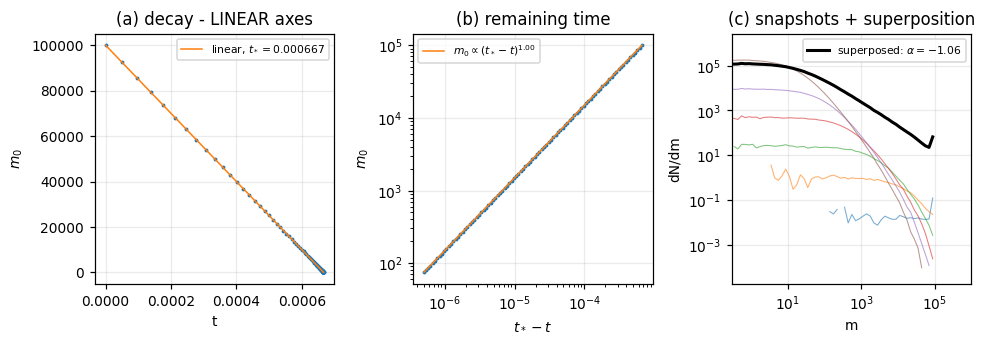

In [5]:
fig, ax = plt.subplots(1, 3)
ax[0].plot(r2["t"], r2["m_mean"], ".", ms=3)
tt = np.linspace(0, r2["t"][-1], 50)
ax[0].plot(tt, np.polyval(p, tt), "-", lw=1, label=r"linear, $t_*=%.3g$" % t_star)
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"$m_0$"); ax[0].legend(fontsize=7)
ax[0].set_title("(a) decay - LINEAR axes")

x = t_star*1.0000001 - r2["t"][sel2]
ax[1].loglog(x, r2["m_mean"][sel2], ".", ms=3)
ax[1].loglog(x, r2["m_mean"][sel2][0]*(x/x[0])**g2["b"], "-", lw=1,
             label=r"$m_0\propto (t_*-t)^{%.2f}$" % g2["b"])
ax[1].set_xlabel(r"$t_*-t$"); ax[1].set_ylabel(r"$m_0$"); ax[1].legend(fontsize=7)
ax[1].set_title("(b) remaining time")

for k in np.linspace(3, len(r2["t"])-1, 6).astype(int):
    ax[2].loglog(r2["centers"], np.where(r2["dndm"][k]>0, r2["dndm"][k], np.nan), lw=.7, alpha=.6)
ax[2].loglog(r2["centers"], np.where(F2>0, F2/F2.max()*r2["dndm"].max(), np.nan), "k", lw=2,
             label=r"superposed: $\alpha=%.2f$" % f2["alpha"])
ax[2].set_xlim(.3, 1e6); ax[2].set_xlabel("m"); ax[2].set_ylabel("dN/dm")
ax[2].legend(fontsize=7); ax[2].set_title("(c) snapshots + superposition")
fig.tight_layout()

---
## Summary

One row per case. `plateau` is the longest flat run in $\Gamma(m)=d\log F/d\log m$, with its
scatter and its width in decades; `guard` is the a-priori band fit, kept as an independent
cross-check. The two must agree.

Read `dec` before believing `plateau`: a plateau narrower than about one decade is not a
power law, however clean its error bar looks. Case 2 is the cautionary example — the passive
floor freezes everything below `FLOOR` into a flat shelf that is four decades wide and has
nothing to do with the cascade, so the plateau search there is restricted to $m\ge$`FLOOR`.
Left unrestricted it returns $\alpha\simeq0$ with a beautiful error bar.


In [6]:
hdr = ("%-22s | %7s %7s | %8s %7s %6s | %8s %8s" %
       ("case", "b", "b_th", "plateau", "+-", "dec", "guard", "theory"))
print(hdr); print("-" * len(hdr))
for name, d in RESULTS.items():
    print("%-22s | %7.3f %7.3f | %+8.3f %7.3f %6.2f | %+8.3f %+8.3f" %
          (name, d["b"], d["b_th"], d["alpha"], d["scatter"], d["decades"],
           d["alpha_gb"], d["alpha_th"]))
print("\nplateau = find_inertial_range (longest flat run in the local slope).")
print("guard   = the a-priori band fit.  The two must agree.")
print("dec     = plateau width in decades; below ~1 the index is not a measurement.")


case                   |       b    b_th |  plateau      +-    dec |    guard   theory
--------------------------------------------------------------------------------------
1 closed coag          |   0.990   1.000 |   -1.077   0.126   2.70 |   -1.035   -1.000
2 closed frag          |   1.001   1.000 |   -0.978   0.141   3.00 |   -1.056   -1.000

plateau = find_inertial_range (longest flat run in the local slope).
guard   = the a-priori band fit.  The two must agree.
dec     = plateau width in decades; below ~1 the index is not a measurement.
